## Import data, create P(dgeom)


In [1]:
import polars as pl
from tcrtrifold.tcrdock_utils import (
    dgeom_ndarr_from_dgeom_series,
    mn_distr_from_dgeom_ndarr,
    mn_distance_from,
    un_cossin_embed,
)
from tcrtrifold.utils import filter_to_cog_thresh, FORMAT_ANTIGEN_COLS, FORMAT_TCR_COLS


iedb_II_conf = (
    pl.read_parquet("../../data/iedb_II/triad/iedb_II_triad.conf_af3.parquet")
    .drop(["receptor_id", "references"])
    .join(
        pl.read_parquet(
            "../../data/iedb_II/triad/iedb_II_triad.receptor_reference.parquet"
        ).select("job_name", "receptor_id", "references"),
        on="job_name",
        how="left",
    )
)
iedb_II_tcrdock = pl.read_parquet(
    "../../data/iedb_II/triad/staged/iedb_II_triad.af3_tcrdock.parquet"
)

iedb_II = iedb_II_conf.join(
    iedb_II_tcrdock.select("pred_dgeom_4", "job_name").with_columns(
        pl.col("pred_dgeom_4").struct.unnest()
    ),
    on="job_name",
    how="inner",
)

template_dgeom = pl.read_csv(
    "../../data/pdb/raw/ternary_templates_v2.tsv", separator="\t"
).with_columns(
    pl.struct(
        **{
            k: pl.col(k)
            for k in [
                "d",
                "torsion",
                "mhc_unit_x_is_negative",
                "tcr_unit_y",
                "tcr_unit_z",
                "tcr_unit_x_is_negative",
                "mhc_unit_y",
                "mhc_unit_z",
            ]
        }
    ).alias("dgeom"),
    pl.when(pl.col("mhc_class") == 1)
    .then(pl.lit("I"))
    .otherwise(pl.lit("II"))
    .alias("mhc_class"),
)

class_II_t_dgeom = dgeom_ndarr_from_dgeom_series(
    template_dgeom.filter(pl.col("mhc_class") == "II").select("dgeom").to_series()
)

class_II_distr = mn_distr_from_dgeom_ndarr(class_II_t_dgeom)

_, iedb_II_p_dgeom = mn_distance_from(
    dgeom_ndarr_from_dgeom_series(iedb_II.select("pred_dgeom_4").to_series()),
    *class_II_distr,
)

iedb_II = iedb_II.with_columns(pl.Series(name="p_dgeom", values=iedb_II_p_dgeom))

iedb_II = iedb_II.explode("receptor_id", "references")


iedb_I_conf = (
    pl.read_parquet("../../data/iedb_I/triad/iedb_I_triad.conf_af3.parquet")
    .drop(["receptor_id", "references"])
    .join(
        pl.read_parquet(
            "../../data/iedb_I/triad/iedb_I_triad.receptor_reference.parquet"
        ).select("job_name", "receptor_id", "references"),
        on="job_name",
        how="left",
    )
)
iedb_I = iedb_I_conf
iedb_I_tcrdock = pl.read_parquet(
    "../../data/iedb_I/triad/staged/iedb_I_triad.af3_tcrdock.parquet"
)

iedb_I = iedb_I_conf.join(
    iedb_I_tcrdock.select("pred_dgeom_4", "job_name").with_columns(
        pl.col("pred_dgeom_4").struct.unnest()
    ),
    on="job_name",
    how="inner",
)

class_I_t_dgeom = dgeom_ndarr_from_dgeom_series(
    template_dgeom.filter(pl.col("mhc_class") == "I").select("dgeom").to_series()
)

class_I_distr = mn_distr_from_dgeom_ndarr(class_I_t_dgeom)

_, iedb_I_p_dgeom = mn_distance_from(
    dgeom_ndarr_from_dgeom_series(iedb_I.select("pred_dgeom_4").to_series()),
    *class_I_distr,
)

iedb_I = iedb_I.with_columns(pl.Series(name="p_dgeom", values=iedb_I_p_dgeom))

iedb_I = iedb_I.explode("receptor_id", "references")

# REMOVEME TO ADD BACK IN
iedb_II_annot = pl.read_parquet(
    "../../data/iedb_II_full/triad/iedb_II_triad.annotated.parquet"
).filter(pl.col("triad_in_pdb"))

iedb_II = iedb_II.join(iedb_II_annot, on="job_name", how="anti")

# REMOVEME TO ADD BACK IN
iedb_I_annot = pl.read_parquet(
    "../../data/iedb_I_full/triad/iedb_I_triad.annotated.parquet"
).filter(pl.col("triad_in_pdb"))

iedb_I = iedb_I.join(iedb_I_annot, on="job_name", how="anti")

# additionally filter out
iedb_I = iedb_I.filter(pl.col("job_name") != "121f50b609621ebe92777820dad90eb9")

## Summary nums


### AUC unit resolution


In [ ]:
iedb_I.group_by(FORMAT_ANTIGEN_COLS).agg(
    pl.col("cognate").sum().alias("cog_total"), pl.len().alias("total")
).filter(pl.col("cog_total") > 0).with_columns(
    (pl.col("cog_total") * (pl.col("total") - pl.col("cog_total"))).alias("cog_prod")
).filter(
    pl.col("cog_prod") < 100
)

peptide,mhc_class,mhc_1_chain,mhc_1_species,mhc_1_name,mhc_1_seq,mhc_2_chain,mhc_2_species,mhc_2_name,mhc_2_seq,cog_total,total,cog_prod
str,str,str,str,str,str,str,str,str,str,u32,u32,u32


In [13]:
iedb_II.group_by(FORMAT_ANTIGEN_COLS).agg(
    pl.col("cognate").sum().alias("cog_total"), pl.len().alias("total")
).filter(pl.col("cog_total") > 0).with_columns(
    (pl.col("cog_total") * (pl.col("total") - pl.col("cog_total"))).alias("cog_prod")
).filter(
    pl.col("cog_prod") < 100
)

peptide,mhc_class,mhc_1_chain,mhc_1_species,mhc_1_name,mhc_1_seq,mhc_2_chain,mhc_2_species,mhc_2_name,mhc_2_seq,cog_total,total,cog_prod
str,str,str,str,str,str,str,str,str,str,u32,u32,u32


In [3]:
print(
    f"Num iedb II: {iedb_II.filter(pl.col('cognate')).select('job_name').unique().height}"
)
print(
    f"Num iedb I: {iedb_I.filter(pl.col('cognate')).select('job_name').unique().height}"
)
print(
    f"Num noncog iedb II: {iedb_II.filter(~pl.col('cognate')).select('job_name').unique().height}"
)
print(
    f"Num noncog iedb I: {iedb_I.filter(~pl.col('cognate')).select('job_name').unique().height}"
)

Num iedb II: 1612
Num iedb I: 7702
Num noncog iedb II: 34144
Num noncog iedb I: 157025


In [4]:
print(f"Num iedb II TCR: {iedb_II.select(FORMAT_TCR_COLS).unique().height}")
print(f"Num iedb I TCR: {iedb_I.select(FORMAT_TCR_COLS).unique().height}")

Num iedb II TCR: 1312
Num iedb I TCR: 7519


In [6]:
print(
    f"Num iedb II antigen: {iedb_II.filter(pl.col("cognate")).select(FORMAT_ANTIGEN_COLS).unique().height}"
)
print(
    f"Num iedb I antigen: {iedb_I.filter(pl.col("cognate")).select(FORMAT_ANTIGEN_COLS).unique().height}"
)

Num iedb II antigen: 244
Num iedb I antigen: 932


In [7]:
print(
    f"Num iedb II HLA: {iedb_II.filter(pl.col("cognate")).select('mhc_1_name', 'mhc_2_name').unique().height}"
)
print(
    f"Num iedb I HLA: {iedb_I.filter(pl.col("cognate")).select('mhc_1_name', 'mhc_2_name').unique().height}"
)

Num iedb II HLA: 33
Num iedb I HLA: 38


In [8]:
excl_I = pl.read_parquet(
    "../../data/iedb_I/triad/staged/iedb_I_triad.excluded_triad.parquet"
)

excl_II = pl.read_parquet(
    "../../data/iedb_II/triad/staged/iedb_II_triad.excluded_triad.parquet"
)

print(f"Num excl IEDB I: {excl_I.height}")
print(f"Num excl IEDB II: {excl_II.height}")

Num excl IEDB I: 8
Num excl IEDB II: 6


## Helper methods + lists


In [2]:
from tcrtrifold.utils import FORMAT_ANTIGEN_COLS
from tcrtrifold.eval_utils import antigen_raw_score_auc
import sklearn.metrics as metrics
from scipy.stats import wilcoxon, norm, false_discovery_control
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from collections import OrderedDict, defaultdict
import polars as pl
from matplotlib.patches import Patch
import matplotlib.colors as mcolors
from adjustText import adjust_text


def auc_by(
    df, featnames, feat_type, grouping_cols=FORMAT_ANTIGEN_COLS + ["references"]
):

    antigen_st = df.filter(pl.col("cognate")).select(grouping_cols).unique()

    feat_df = []

    for row in antigen_st.iter_rows(named=True):

        focal_a_st = pl.DataFrame([row]).select(pl.exclude("job_name"))
        focal_pos = df.join(focal_a_st, on=grouping_cols)
        focal_neg = df.join(
            focal_pos.select(FORMAT_ANTIGEN_COLS).unique(),
            on=FORMAT_ANTIGEN_COLS,
        ).filter(~pl.col("cognate"))

        focal_triad = pl.concat([focal_pos, focal_neg])

        for feat, ft in zip(featnames, feat_type):
            dat = focal_triad.select(feat, "cognate").to_numpy()

            fpr, tpr, threshold = metrics.roc_curve(dat[:, 1], dat[:, 0])
            # roc_auc = abs(metrics.auc(fpr, tpr) - 0.5) + 0.5
            roc_auc = metrics.auc(fpr, tpr)

            feat_df.append(
                {
                    "auc": roc_auc,
                    # "fpr": list(fpr),
                    # "tpr": list(tpr),
                    "featname": feat,
                    "feat_type": ft,
                }
            )

    feat_df = pl.DataFrame(feat_df)

    return feat_df


def plot_violins(label, values, categories, cell_w=1.8, cell_h=1.5, suptitle=None):
    """
    label, values, categories: same-length lists
      - One row per category (its own color)
      - Within a row, labels present are left-aligned (no internal gaps)
      - Each cell is a single violin; all cells have identical size
      - Mean annotated as 'AUC: {mean:.3f}'
    """
    if not (len(label) == len(values) == len(categories)):
        raise ValueError("label, values, categories must have the same length")

    # Preserve first-seen order
    cats_order = list(OrderedDict.fromkeys(categories))

    # Build data: cat -> OrderedDict(label -> concatenated ndarray)
    by_cat = OrderedDict()
    for c in cats_order:
        by_cat[c] = OrderedDict()

    for lab, vals, cat in zip(label, values, categories):
        if vals is None:
            continue
        arr = np.asarray(vals)
        if arr.size == 0:
            continue
        od = by_cat[cat]
        od[lab] = arr if lab not in od else np.concatenate([od[lab], arr])

    # Drop categories that ended up empty
    cats_order = [c for c in cats_order if len(by_cat[c]) > 0]
    if not cats_order:
        raise ValueError("No non-empty data found to plot.")

    # Global y-limits for comparability
    gmin, gmax = None, None
    for c in cats_order:
        for arr in by_cat[c].values():
            if arr.size:
                a0, a1 = np.nanmin(arr), np.nanmax(arr)
                gmin = a0 if gmin is None else min(gmin, a0)
                gmax = a1 if gmax is None else max(gmax, a1)
    yr = (gmax - gmin) if gmin is not None else 1.0
    if yr == 0:
        yr = 1.0
    ypad = 0.05 * yr
    ylims = (gmin - ypad, gmax + ypad)

    # Fixed grid width = max number of columns any row needs
    max_cols = max(len(by_cat[c]) for c in cats_order)
    R = len(cats_order)

    # Figure size scales with max_cols and R → constant cell size
    fig = plt.figure(figsize=(max(6, cell_w * max_cols), max(4, cell_h * R)))
    gs = fig.add_gridspec(nrows=R, ncols=max_cols, hspace=0.35, wspace=0.25)

    # Category colors
    palette = (
        plt.rcParams["axes.prop_cycle"]
        .by_key()
        .get("color", [f"C{i}" for i in range(10)])
    )
    cat_color = {cat: palette[i % len(palette)] for i, cat in enumerate(cats_order)}

    axes_rows = []
    for i, cat in enumerate(cats_order):
        labs_row = list(by_cat[cat].keys())
        ncols_i = len(labs_row)
        row_axes = []
        for j in range(ncols_i):
            ax = fig.add_subplot(gs[i, j])
            row_axes.append(ax)

            lab_j = labs_row[j]
            data = by_cat[cat][lab_j]

            vp = ax.violinplot(data, widths=0.8, showmedians=True, showextrema=False)
            # Style
            for body in vp["bodies"]:
                body.set_alpha(0.7)
                body.set_facecolor(cat_color[cat])
                body.set_edgecolor("black")
            if "cmedians" in vp:
                vp["cmedians"].set_color("black")

            # Annotate mean
            m = float(np.nanmean(data))
            ax.text(
                1.0,
                m + 0.01 * yr,
                f"AUC: {m:.3f}",
                ha="center",
                va="top",
                fontsize=9,
                bbox=dict(boxstyle="round,pad=0.3", alpha=0.3),
            )

            ax.set_xlim(0.5, 1.5)
            ax.set_ylim(*ylims)
            ax.set_xticks([])
            if j == 0:
                ax.set_ylabel(cat)
            ax.set_title(lab_j, fontsize=8)

        # Leave the remaining cells in this row empty (preserves constant cell size)
        axes_rows.append(row_axes)

    # Legend for categories
    # handles = [mpatches.Patch(color=cat_color[c], label=c) for c in cats_order]
    # fig.legend(handles=handles, title="Category", loc="upper right", frameon=False)
    if suptitle:
        fig.suptitle(suptitle, fontsize=16)

    plt.tight_layout()
    return fig, axes_rows


def spearman_corr_matrix(df: pl.DataFrame, columns) -> pl.DataFrame:

    # rank-transform columns
    ranked = df.select([pl.col(c).rank("average").alias(c) for c in columns])
    # Pearson on ranks = Spearman
    corr = np.corrcoef(ranked.to_numpy(), rowvar=False)
    # build a labeled square matrix in Polars
    mat = pl.DataFrame({c: corr[:, i] for i, c in enumerate(columns)})
    mat = mat.with_columns(var1=pl.Series(columns)).select("var1", *columns)
    return mat


def plot_polars_table(
    df_pl: pl.DataFrame,
    feat_type_colors: (
        dict[str, str] | None
    ) = None,  # e.g. {"geom":"#4e79a7", "phys":"#e15759"}
    show_legend: bool = True,
) -> plt.Figure:
    """
    Render a Polars DataFrame (featname, feat_type, median_auc) as a matplotlib table.
    Colors the feat_type column by category using feat_type_colors (or an auto palette).
    """
    required = ["featname", "feat_type", "median_auc"]
    missing = [c for c in required if c not in df_pl.columns]
    if missing:
        raise ValueError(f"Missing columns: {missing}")

    df = df_pl.select(required).with_columns(
        pl.col("median_auc").cast(pl.Float64).round(3)
    )

    headers = required
    feat_types = df.get_column("feat_type").to_list()

    # Build default color map if none provided
    if feat_type_colors is None:
        uniq = list(dict.fromkeys(feat_types))  # stable order
        uniq.sort()
        cmap = plt.get_cmap("tab20")
        feat_type_colors = {
            u: mcolors.to_hex(cmap(i % cmap.N)) for i, u in enumerate(uniq)
        }

    # Table data as strings
    data = df.to_numpy()
    cell_text = [[str(v) for v in row] for row in data]

    # Column widths heuristic
    col_lens = [
        max(len(headers[i]), max((len(r[i]) for r in cell_text), default=0))
        for i in range(len(headers))
    ]
    total = max(1, sum(col_lens))
    col_widths = [0.98 * L / total for L in col_lens]

    # Figure size
    nrows = len(cell_text) + 1
    fig_w = min(max(total * 0.12, 6), 20)
    fig_h = min(max(nrows * 0.35, 1.5), 20)

    fig, ax = plt.subplots(figsize=(fig_w, fig_h))
    ax.axis("off")
    tbl = ax.table(
        cellText=cell_text,
        colLabels=headers,
        loc="center",
        colWidths=col_widths,
    )
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(10)
    tbl.scale(1, 1.2)

    # Helper: pick readable text color for a background
    def text_color_for(bg):
        r, g, b, _ = mcolors.to_rgba(bg)
        L = 0.2126 * r + 0.7152 * g + 0.0722 * b  # relative luminance
        return "black" if L > 0.6 else "white"

    # Style header
    for c in range(len(headers)):
        cell = tbl[(0, c)]
        cell.set_text_props(weight="bold")
        cell.set_facecolor("#eeeeee")

    # Color feat_type column by category; zebra-strip other cells
    col_ft = headers.index("feat_type")
    for r in range(1, nrows):
        # zebra for non-feat_type cells
        stripe = "#f7f7f7" if r % 2 == 1 else "white"
        for c in range(len(headers)):
            cell = tbl[(r, c)]
            if c != col_ft:
                cell.set_facecolor(stripe)

        # color the feat_type cell
        cat = feat_types[r - 1]
        bg = feat_type_colors.get(cat, "#dddddd")
        ft_cell = tbl[(r, col_ft)]
        ft_cell.set_facecolor(bg)
        ft_cell.get_text().set_color(text_color_for(bg))

    # Optional legend
    if show_legend:
        handles = [
            Patch(facecolor=feat_type_colors[k], edgecolor="black", label=str(k))
            for k in feat_type_colors
        ]
        ax.legend(handles=handles, title="feat_type", loc="upper right", framealpha=0.9)

    fig.tight_layout()
    return fig


def volcano_df(
    df,
    featnames,
    feat_type,
    grouping_cols=FORMAT_ANTIGEN_COLS + ["references"],
    title=None,
):

    antigens = df.filter(pl.col("cognate")).select(grouping_cols).unique()

    feat_df = []

    for row in antigens.iter_rows(named=True):

        focal_a_st = pl.DataFrame([row]).select(pl.exclude("job_name"))
        focal_pos = df.join(focal_a_st, on=grouping_cols)
        focal_neg = df.join(
            focal_pos.select(FORMAT_ANTIGEN_COLS).unique(),
            on=FORMAT_ANTIGEN_COLS,
        ).filter(~pl.col("cognate"))
        focal_triad = pl.concat([focal_pos, focal_neg])
        grp = focal_a_st.select(pl.concat_str(grouping_cols)).item()

        for feat, ft in zip(featnames, feat_type):

            dat = focal_triad.select(feat, "cognate").to_numpy()

            fpr, tpr, threshold = metrics.roc_curve(dat[:, 1], dat[:, 0])
            auc_01 = metrics.roc_auc_score(dat[:, 1], dat[:, 0], max_fpr=0.1)
            # roc_auc = abs(metrics.auc(fpr, tpr) - 0.5) + 0.5
            roc_auc = metrics.auc(fpr, tpr)

            # aucs.append(roc_auc)
            # auc01s.append(auc_01)

            # n_pos.append(focal_pos.height)

            # print(pval)

            feat_df.append(
                {
                    "auc": roc_auc,
                    "auc_01": auc_01,
                    "featname": feat,
                    "feat_type": ft,
                    # "pval": pval,
                    "n_pos": focal_pos.height,
                    "group": grp,
                }
            )

    # stat, pval = wilcoxon(np.array(aucs) - 0.5, alternative="two-sided")

    feat_df = pl.DataFrame(feat_df)

    feat_df = (
        feat_df.group_by("featname", "feat_type")
        .agg(pl.col("auc"), pl.col("auc_01"), pl.col("n_pos"))
        .with_columns(
            pl.col("auc").list.median(),
            pl.col("auc_01").list.median(),
            pl.col("auc").alias("auc_list"),
            pl.col("auc")
            .map_elements(
                lambda x: wilcoxon(np.array(x) - 0.5, alternative="two-sided")[1],
                return_dtype=pl.Float64,
            )
            .alias("pval"),
        )
    )

    return feat_df


# def plot_volcano(feat_df, title=None):

#     aucs = feat_df.select("auc").to_series().to_numpy()
#     pvals = feat_df.select("pval").to_series().to_numpy()
#     featnames = feat_df.select("featname").to_series().to_numpy()
#     feat_types = feat_df.select("feat_type").to_series().to_list()

#     neglog10p = -np.log10(np.array(pvals))

#     fig, ax = plt.subplots(figsize=(12, 8))
#     ax.axhline(-np.log10(0.05), linestyle=":", linewidth=1, color="k", alpha=0.5)
#     ax.set_xlabel("Median AUC across antigen-study combinations")
#     ax.set_ylabel("-log10(p) of Wilcoxon test")

#     cats = list(dict.fromkeys(feat_types))
#     cmap = plt.cm.get_cmap("tab10", len(cats))
#     color_for = {c: cmap(i) for i, c in enumerate(cats)}
#     for c in cats:
#         m = np.array(feat_types) == c
#         ax.scatter(
#             np.array(aucs)[m],
#             np.array(neglog10p)[m],
#             s=20,
#             color=color_for[c],
#             edgecolors="none",
#             alpha=0.9,
#             label=c,
#         )

#     ax.legend(title="Feature type", loc="lower left")

#     texts = []
#     for i in range(len(featnames)):
#         text = ax.text(
#             aucs[i],
#             neglog10p[i],
#             str(featnames[i]),
#             # textcoords="offset points",
#             # xytext=(4, 4),
#             fontsize=8,
#         )
#         texts.append(text)

#     adjust_text(
#         texts,
#         time_lim=5,
#         expand=(1.2, 2),
#         arrowprops=dict(arrowstyle="->", color="black"),
#         max_move=(30, 30),
#         force_text=(0.2, 0.3),
#         target_x=[1] * len(texts),
#         target_y=[1] * len(texts),
#     )

#     if title:
#         ax.set_title(title)


def plot_volcano(feat_df, title=None, pad_frac_x=0.06, pad_frac_y=0.03):
    aucs = feat_df.select("auc").to_series().to_numpy()
    pvals = feat_df.select("pval").to_series().to_numpy()
    featnames = feat_df.select("featname").to_series().to_numpy()
    feat_types = feat_df.select("feat_type").to_series().to_list()

    neglog10p = -np.log10(np.array(pvals))

    fig, ax = plt.subplots(figsize=(12, 8))
    ax.axhline(-np.log10(0.05), linestyle="--", linewidth=2, color="black", alpha=1)
    ax.set_xlabel("Median AUC across antigen-study combinations", fontsize=18)
    ax.set_ylabel("-log10(p) of Wilcoxon test", labelpad=240, fontsize=18)
    ax.tick_params(axis="y", labelsize=12)
    ax.tick_params(axis="x", labelsize=12)

    # scatter by type
    cats = list(dict.fromkeys(feat_types))
    # cmap = plt.cm.get_cmap("tab10", len(cats))
    color_for = {
        "docking": (0.3, 0.3, 1.0),
        "interface": (1.0, 0.0, 0.0),
        "local": (1.0, 0.2, 0.8),
        "summary": (0.0, 1.0, 1.0),
    }
    for c in cats:
        m = np.array(feat_types) == c
        ax.scatter(
            np.array(aucs)[m],
            np.array(neglog10p)[m],
            s=50,
            color=color_for[c],
            edgecolors="none",
            alpha=0.8,
            label=c,
        )
    ax.legend(title="Feature type", loc="lower left", fontsize=14, title_fontsize=14)

    # --- establish base limits and padded label columns ---
    # Keep AUC in [0,1]; pad a bit for arrows/labels
    x0, x1 = 0.0, 1.0
    y0 = float(np.nanmin(neglog10p))
    y1 = float(np.nanmax(neglog10p))
    dx = x1 - x0
    dy = y1 - y0
    xpad = pad_frac_x * dx if dx > 0 else 0.05
    ypad = pad_frac_y * dy if dy > 0 else 0.1

    ax.set_xlim(x0, x1)
    ax.set_ylim(y0 - ypad, y1 + ypad)

    # Label columns (fixed x in data coords, outside the axes)
    left_col_x = x0 - xpad * 0.8
    right_col_x = x1 + xpad * 0.8

    # --- split into left/right groups ---
    left_idx = np.where(aucs < 0.5)[0]
    right_idx = np.where(aucs >= 0.5)[0]

    # Sort each side by y to get a nice vertical order
    left_sorted = left_idx[np.argsort(neglog10p[left_idx])]
    right_sorted = right_idx[np.argsort(neglog10p[right_idx])]

    # Evenly spaced y targets (two tidy vertical stacks)
    def stack_y(sorted_idx):
        n = len(sorted_idx)
        if n == 0:
            return np.array([])
        # Distribute labels in the interior of the axis to avoid hugging edges
        return np.linspace(y0 + 0.02 * (y1 - y0), y1 - 0.02 * (y1 - y0), n)

    left_y_targets = stack_y(left_sorted)
    right_y_targets = stack_y(right_sorted)

    # --- annotate: arrows from points to label columns; labels aligned in two stacks ---
    def place_side(sorted_idx, y_targets, col_x, ha):
        for i, idx in enumerate(sorted_idx):
            # arrow from point to the column y target
            ax.annotate(
                "",  # just the arrow
                xy=(col_x, y_targets[i]),
                xycoords="data",
                xytext=(aucs[idx], neglog10p[idx]),
                textcoords="data",
                arrowprops=dict(arrowstyle="-", color="grey", lw=0.5),
                annotation_clip=False,
            )
            # the text label at the column
            ax.text(
                col_x,
                y_targets[i],
                str(featnames[idx]),
                ha=ha,
                va="center",
                fontsize=14,
                color=color_for[feat_types[idx]],
                clip_on=False,
            )

    place_side(left_sorted, left_y_targets, left_col_x, ha="right")
    place_side(right_sorted, right_y_targets, right_col_x, ha="left")

    # Re-assert main data limits (so the off-axes labels don’t expand the view)
    ax.set_xlim(x0, x1)
    ax.set_ylim(y0 - ypad, y1 + ypad)

    if title:
        ax.set_title(title, fontsize=20)

    # fig.canvas.draw()  # ensure text extents are real
    # renderer = fig.canvas.get_renderer()

    # # collect left-column texts: we created them at x=left_col_x with ha="right"
    # left_texts = []
    # for artist in ax.texts:
    #     # these are your column labels (outside axes) with ha='right' at left_col_x
    #     if artist.get_ha() == "right" and np.isfinite(artist.get_position()[0]) and artist.get_clip_on() is False:
    #         left_texts.append(artist)

    # if left_texts:
    #     # min X among left labels in display coords
    #     min_x_px = min(t.get_window_extent(renderer=renderer).xmin for t in left_texts)
    # else:
    #     # fallback: left edge of axes in display coords
    #     min_x_px = ax.get_window_extent(renderer=renderer).xmin

    # pad_px = 10  # extra gap between ylabel and left label column
    # ylabel_x_px = max(0, min_x_px - pad_px)

    # # 2) convert pixel X to figure fraction and place a figure-level text
    # fig_w_px = fig.get_figwidth() * fig.dpi
    # fig_h_px = fig.get_figheight() * fig.dpi
    # fig_x = ylabel_x_px / fig_w_px
    # fig_y = 0.5 * (ax.get_position().y0 + ax.get_position().y1)  # center vertically in fig coords

    # # remove normal axes ylabel, add figure-level one
    # ax.set_ylabel("")
    # fig.text(
    #     fig_x, fig_y, "-log10(p) of Wilcoxon test",  # <-- your y label text here
    #     rotation=90, va="center", ha="center",
    #     fontsize=ax.yaxis.label.get_size() if ax.yaxis.get_label().get_text() else 12,
    #     transform=fig.transFigure,
    # )

    return fig, ax


docking_feats = [
    "d",
    "mhc_unit_y",
    "mhc_unit_z",
    "tcr_unit_y",
    "tcr_unit_z",
    "torsion",
    "p_dgeom",
]

interface_feats = [
    "mean_p_tcr_pae",
    "mean_tcr_p_pae",
    "mean_mhc_tcr_pae",
    "mean_tcr_mhc_pae",
    "mean_p_tcr_contact_prob",
    "mean_tcr_p_contact_prob",
    "mean_mhc_tcr_contact_prob",
    "mean_tcr_mhc_contact_prob",
    "mean_p_tcr_interface_pae",
    "mean_tcr_p_interface_pae",
    "mean_tcr_pmhc_interface_pae",
    "mean_pmhc_tcr_interface_pae",
    "mean_p_tcr_interface_contact_prob",
    "mean_tcr_p_interface_contact_prob",
    "mean_tcr_pmhc_interface_contact_prob",
    "mean_pmhc_tcr_interface_contact_prob",
    "mean_p_mhc_pae",
    "mean_mhc_p_pae",
    "mean_mhc_p_interface_pae",
    "mean_p_mhc_interface_pae",
    # "mean_mhc_p_contact_prob",
    # "mean_p_mhc_contact_prob",
    "min_p_tcr_pae",
    "min_mhc_tcr_pae",
    "min_tcr_p_pae",
    "min_tcr_mhc_pae",
    "tcr_mhc_contacts",
    "tcr_p_contacts",
]


local_feats_II = [
    "peptide_mean_pLDDT",
    "peptide_mean_pLDDT_II",
    "tcr_1_cdr_1_mean_pLDDT",
    "tcr_1_cdr_2_mean_pLDDT",
    "tcr_1_cdr_2_5_mean_pLDDT",
    "tcr_1_cdr_3_mean_pLDDT",
    "tcr_2_cdr_1_mean_pLDDT",
    "tcr_2_cdr_2_mean_pLDDT",
    "tcr_2_cdr_2_5_mean_pLDDT",
    "tcr_2_cdr_3_mean_pLDDT",
    "tcr_cdrs_mean_pLDDT",
    "mhc_helices_mean_pLDDT",
]


local_feats_I = [
    "peptide_mean_pLDDT",
    "tcr_1_cdr_1_mean_pLDDT",
    "tcr_1_cdr_2_mean_pLDDT",
    "tcr_1_cdr_2_5_mean_pLDDT",
    "tcr_1_cdr_3_mean_pLDDT",
    "tcr_2_cdr_1_mean_pLDDT",
    "tcr_2_cdr_2_mean_pLDDT",
    "tcr_2_cdr_2_5_mean_pLDDT",
    "tcr_2_cdr_3_mean_pLDDT",
    "tcr_cdrs_mean_pLDDT",
    "mhc_helices_mean_pLDDT",
]

summary_feats = [
    "iptm",
    "ptm",
    "ranking_score",
]

featnames_II = docking_feats + interface_feats + local_feats_II + summary_feats
feat_type_II = (
    ["docking"] * len(docking_feats)
    + ["interface"] * len(interface_feats)
    + ["local"] * len(local_feats_II)
    + ["summary"] * len(summary_feats)
)
featnames_I = docking_feats + interface_feats + local_feats_I + summary_feats
feat_type_I = (
    ["docking"] * len(docking_feats)
    + ["interface"] * len(interface_feats)
    + ["local"] * len(local_feats_I)
    + ["summary"] * len(summary_feats)
)

In [31]:
len(interface_feats)

26

## Class II


In [3]:
feat_df_II = volcano_df(
    iedb_II.explode("references"),
    featnames_II,
    feat_type_II,
    title="IEDB Class II Feature AUCs",
)

In [8]:
feat_df_II.sort(by="auc")

featname,feat_type,auc,auc_01,n_pos,auc_list,pval
str,str,f64,f64,list[i64],list[f64],f64
"""mean_p_tcr_interface_pae""","""interface""",0.286111,0.473684,"[2, 1, … 1]","[0.055, 0.06, … 0.14]",2.4109e-16
"""min_tcr_p_pae""","""interface""",0.29,0.473684,"[2, 1, … 1]","[0.0725, 0.12, … 0.225]",5.2309e-15
"""mean_pmhc_tcr_interface_pae""","""interface""",0.29,0.473684,"[2, 1, … 1]","[0.04, 0.04, … 0.36]",2.7442e-15
"""mean_tcr_p_pae""","""interface""",0.290251,0.473684,"[2, 1, … 1]","[0.04, 0.03, … 0.57]",3.8898e-14
"""mean_p_tcr_pae""","""interface""",0.3,0.473684,"[2, 1, … 1]","[0.065, 0.05, … 0.14]",2.8211e-16
…,…,…,…,…,…,…
"""mean_mhc_tcr_contact_prob""","""interface""",0.688725,0.473684,"[2, 1, … 1]","[0.42, 0.93, … 0.95]",9.4732e-11
"""iptm""","""summary""",0.699809,0.473684,"[2, 1, … 1]","[0.93, 0.91, … 0.59]",2.5333e-14
"""ranking_score""","""summary""",0.706564,0.473684,"[2, 1, … 1]","[0.9425, 0.97, … 0.585]",1.5718e-14


In [9]:
feat_df_II.filter(pl.col("featname") == "d").select(pl.col("n_pos").list.len())

n_pos
u32
248


In [10]:
feat_df_II.filter(pl.col("featname") == "d").select(
    pl.col("n_pos").list.min().alias("min_pos"), pl.col("n_pos").list.max()
)

min_pos,n_pos
i64,i64
1,378


In [11]:
feat_df_II.filter(pl.col("featname") == "d").select(pl.col("n_pos").list.mean())

n_pos
f64
6.491935


In [12]:
feat_df_II.select(pl.col("pval").max().alias("max"), pl.col("pval").min().alias("min"))

max,min
f64,f64
0.612719,2.4109e-16


In [13]:
print(feat_df_II.filter(pl.col("pval") < 0.05).height)
print(feat_df_II.height)

44
48


In [14]:
feat_df_II.select(pl.col("auc").max().alias("max"), pl.col("auc").min().alias("min"))

max,min
f64,f64
0.71,0.286111


(<Figure size 1200x800 with 1 Axes>,
 <Axes: title={'center': 'Class II training set feature AUCs'}, xlabel='Median AUC across antigen-study combinations', ylabel='-log10(p) of Wilcoxon test'>)

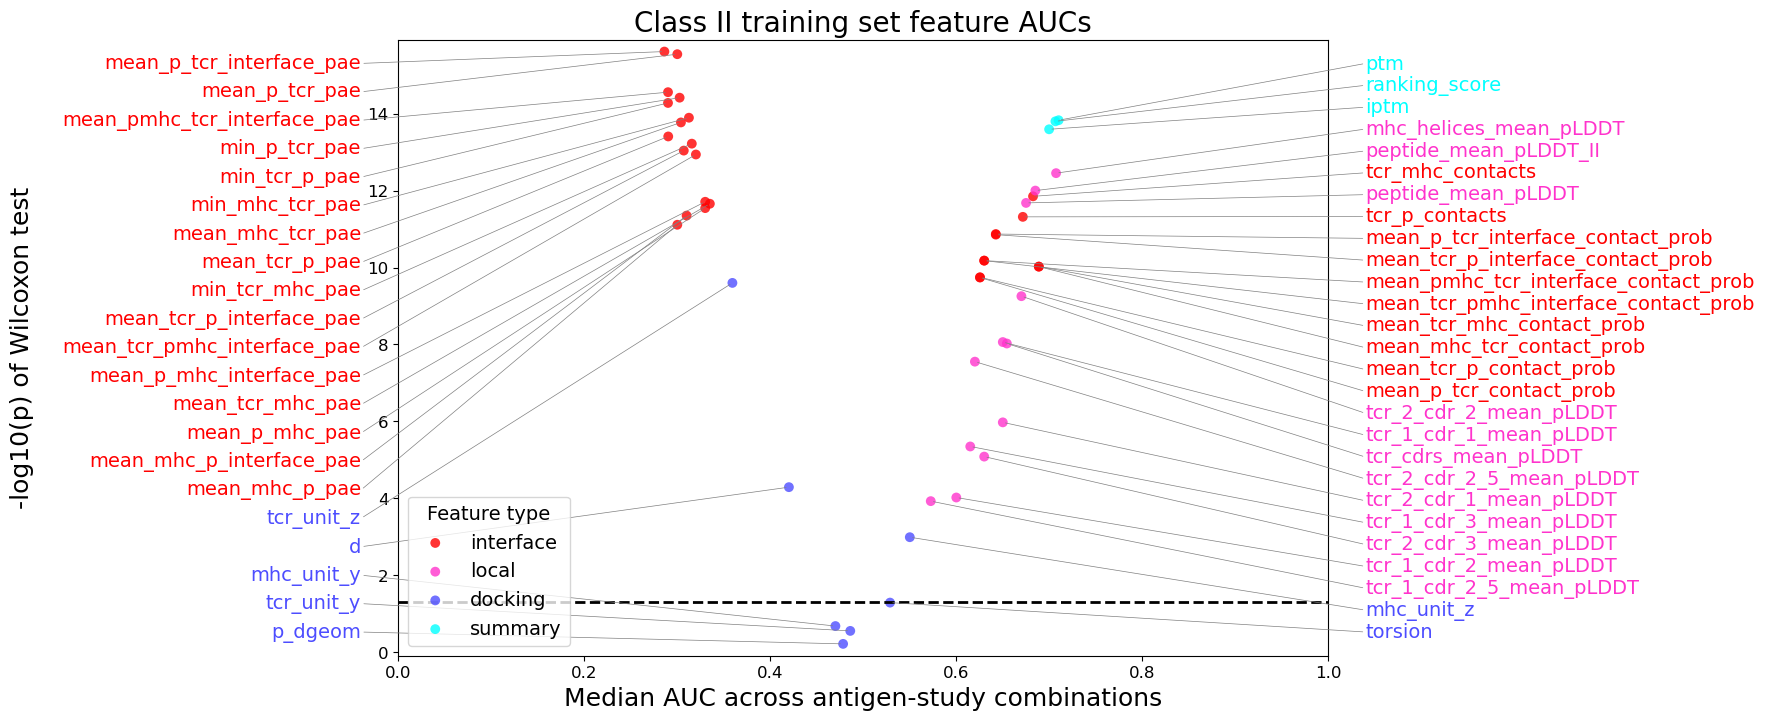

In [4]:
plot_volcano(
    feat_df_II,
    pad_frac_y=0.02,
    pad_frac_x=0.05,
    title="Class II training set feature AUCs",
)

### Method correlation


## Class I


In [5]:
feat_df = volcano_df(
    iedb_I.explode("references"),
    featnames_I,
    feat_type_I,
)

In [35]:
feat_df.with_columns((pl.col("auc") - 0.5).abs() + 0.5).sort(by="auc")

featname,feat_type,auc,auc_01,n_pos,auc_list,pval
str,str,f64,f64,list[i64],list[f64],f64
"""mhc_unit_z""","""docking""",0.51,0.473684,"[2, 1, … 1]","[0.365, 0.82, … 0.88]",0.915468
"""tcr_unit_y""","""docking""",0.515,0.473684,"[2, 1, … 1]","[0.075, 0.38, … 0.52]",0.036281
"""torsion""","""docking""",0.519804,0.473684,"[2, 1, … 1]","[0.415, 0.0, … 0.77]",0.015397
"""d""","""docking""",0.52,0.473684,"[2, 1, … 1]","[0.665, 0.52, … 0.61]",0.007396
"""mhc_unit_y""","""docking""",0.53,0.473684,"[2, 1, … 1]","[0.88, 0.42, … 0.86]",0.00475
…,…,…,…,…,…,…
"""min_tcr_p_pae""","""interface""",0.623713,0.473684,"[2, 1, … 1]","[0.3225, 0.24, … 0.17]",2.2673e-35
"""min_p_tcr_pae""","""interface""",0.625908,0.473684,"[2, 1, … 1]","[0.29, 0.27, … 0.18]",2.7503e-36
"""mean_p_tcr_interface_pae""","""interface""",0.627546,0.473684,"[2, 1, … 1]","[0.56, 0.23, … 0.14]",2.9011e-37


In [51]:
feat_df.filter(pl.col("featname") == "d").select(pl.col("n_pos").list.len())

n_pos
u32
1024


In [52]:
feat_df.filter(pl.col("featname") == "d").select(
    pl.col("n_pos").list.min().alias("min_pos"), pl.col("n_pos").list.max()
)

min_pos,n_pos
i64,i64
1,689


In [19]:
feat_df.filter(pl.col("featname") == "d").select(pl.col("n_pos").list.mean())

n_pos
f64
7.542969


In [20]:
feat_df.select(pl.col("pval").max().alias("max"), pl.col("pval").min().alias("min"))

max,min
f64,f64
0.915468,9.8551e-39


In [21]:
print(feat_df.filter(pl.col("pval") < 0.05).height)
print(feat_df.height)

46
47


In [22]:
feat_df.select(pl.col("auc").max().alias("max"), pl.col("auc").min().alias("min"))

max,min
f64,f64
0.62766,0.372454


(<Figure size 1200x800 with 1 Axes>,
 <Axes: title={'center': 'Class I training set feature AUCs'}, xlabel='Median AUC across antigen-study combinations', ylabel='-log10(p) of Wilcoxon test'>)

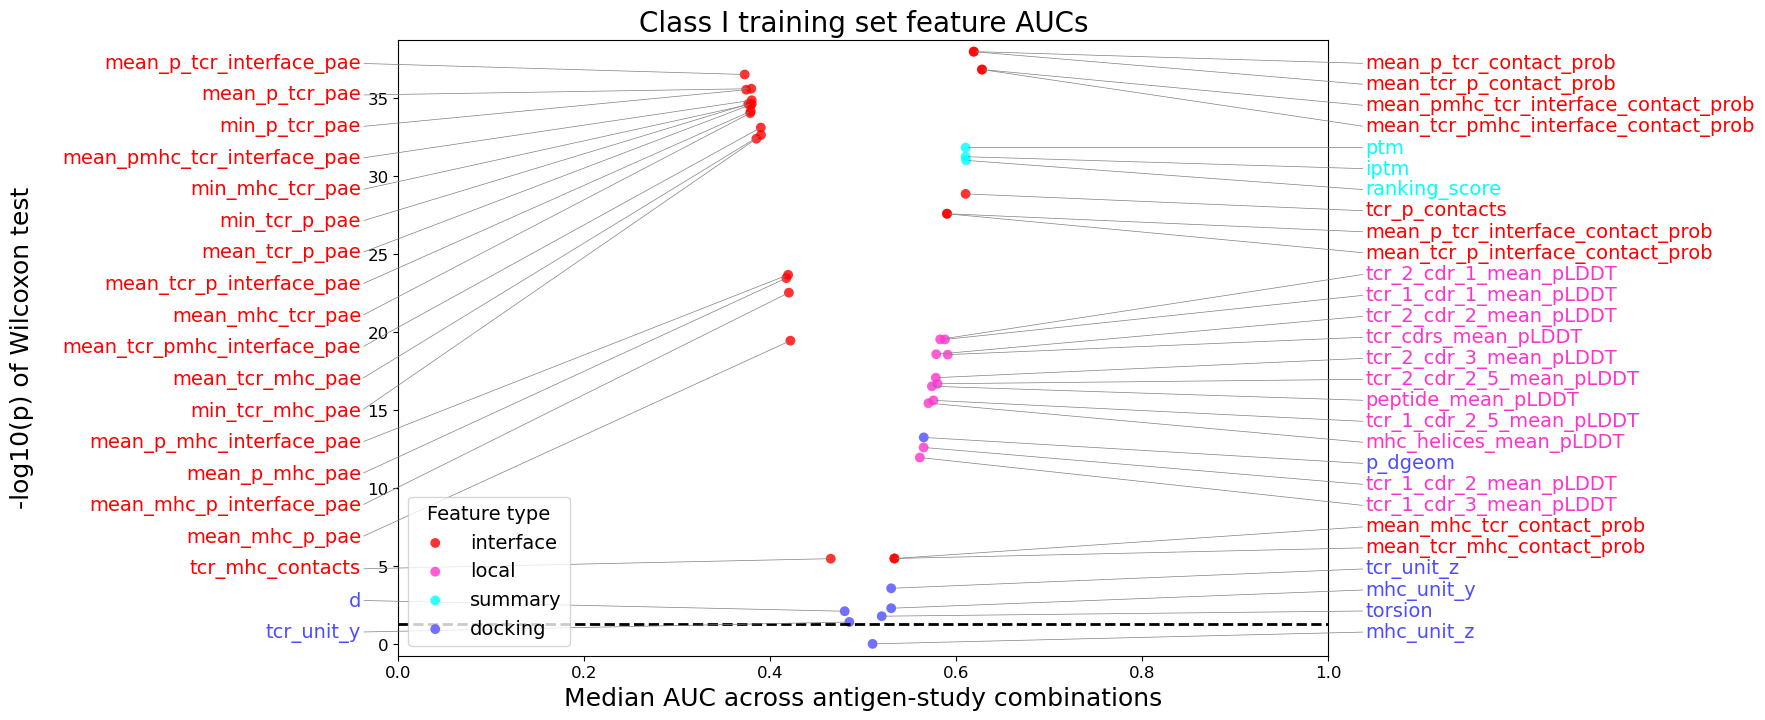

In [6]:
plot_volcano(
    feat_df,
    pad_frac_y=0.02,
    pad_frac_x=0.05,
    # title="IEDB Class I Feature AUCs",
    title="Class I training set feature AUCs",
)

## Correlation heatmap


### Best feat by feat type


In [56]:
ft = feat_df.sort(by="feat_type").partition_by("feat_type", maintain_order=True)
fn_I = []
for ft_df in ft:
    fn_I.extend(
        ft_df.with_columns(
            ((pl.col("auc") - pl.lit(0.5)).abs() + pl.lit(0.5)).alias("auc_n")
        )
        .sort(by="auc_n", descending=True)[:10]
        .select("featname")
        .to_series()
        .to_list()[:2]
    )

ft = feat_df_II.sort(by="feat_type").partition_by("feat_type", maintain_order=True)
fn_II = []
for ft_df in ft:
    fn_II.extend(
        ft_df.with_columns(
            ((pl.col("auc") - pl.lit(0.5)).abs() + pl.lit(0.5)).alias("auc_n")
        )
        .sort(by="auc_n", descending=True)[:10]
        .select("featname")
        .to_series()
        .to_list()[:2]
    )

In [57]:
best_feat_I = (
    feat_df.with_columns(
        ((pl.col("auc") - pl.lit(0.5)).abs() + pl.lit(0.5)).alias("auc_n")
    )
    .sort(by="auc_n", descending=True)[:10]
    .select("featname")
    .to_series()
    .to_list()
)

best_feat_II = (
    feat_df_II.with_columns(
        ((pl.col("auc") - pl.lit(0.5)).abs() + pl.lit(0.5)).alias("auc_n")
    )
    .sort(by="auc_n", descending=True)[:10]
    .select("featname")
    .to_series()
    .to_list()
)

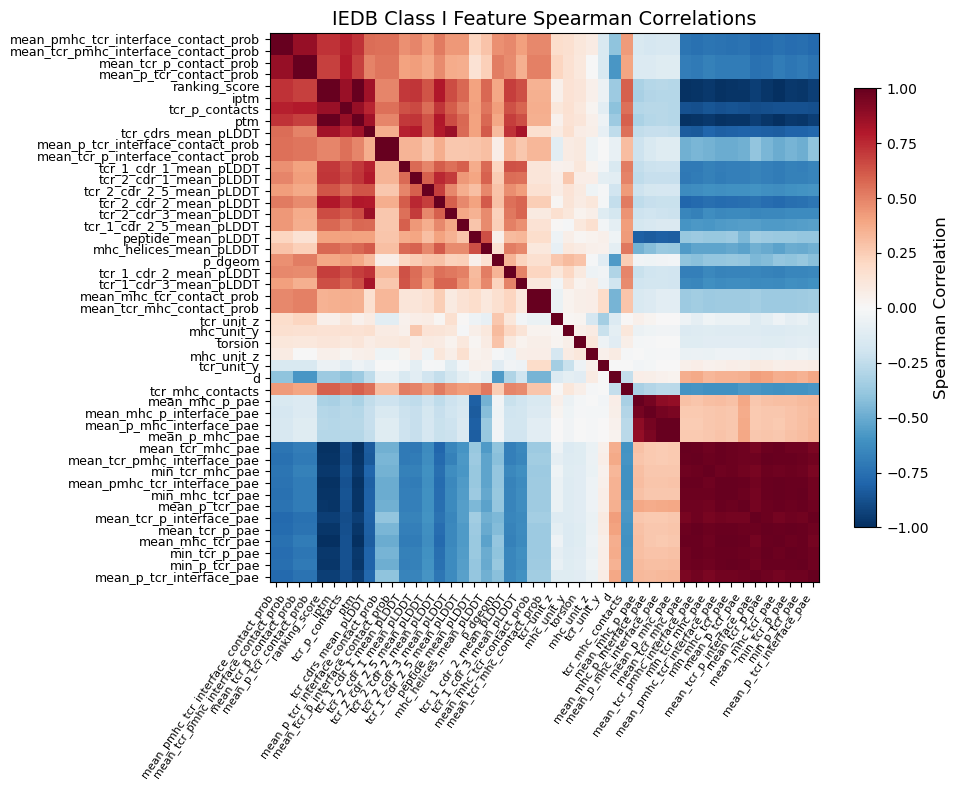

In [7]:
import matplotlib.pyplot as plt
import numpy as np


def plot_spearman_heatmap(
    df: pl.DataFrame,
    feature_columns: list[str] | None = None,
    figsize: tuple[float, float] = (10, 8),
    cmap: str = "RdBu_r",
    title: str | None = None,
) -> plt.Figure:
    """
    Plot pairwise Spearman correlation heatmap using only matplotlib.

    Parameters
    ----------
    df : pl.DataFrame
        Input dataframe with feature columns.
    feature_columns : list[str], optional
        List of column names to include in correlation. If None, uses all numeric columns.
    figsize : tuple[float, float], default=(10, 8)
        Figure size as (width, height).
    cmap : str, default="RdBu_r"
        Colormap for the heatmap.
    title : str, optional
        Plot title.

    Returns
    -------
    plt.Figure
        The matplotlib figure containing the heatmap.
    """

    # Select feature columns
    if feature_columns is None:
        numeric_cols = [
            col
            for col, dtype in zip(df.columns, df.dtypes)
            if dtype in [pl.Float32, pl.Float64, pl.Int32, pl.Int64]
        ]
        feature_columns = numeric_cols

    if not feature_columns:
        raise ValueError("No feature columns found or specified")

    # Compute Spearman correlation matrix
    corr_matrix = spearman_corr_matrix(df, feature_columns)
    corr_values = corr_matrix.select(feature_columns).to_numpy()

    # Create the plot
    fig, ax = plt.subplots(figsize=figsize)

    # Create heatmap
    im = ax.imshow(corr_values, cmap=cmap, vmin=-1, vmax=1, aspect="equal")

    # Add colorbar
    cbar = plt.colorbar(im, ax=ax, shrink=0.8)
    cbar.set_label("Spearman Correlation", fontsize=12)

    # Set ticks and labels
    ax.set_xticks(range(len(feature_columns)))
    ax.set_yticks(range(len(feature_columns)))
    ax.set_xticklabels(feature_columns, rotation=55, ha="right", fontsize=8)
    ax.set_yticklabels(feature_columns, fontsize=9)

    # Add correlation values as text annotations
    for i in range(len(feature_columns)):
        for j in range(len(feature_columns)):
            text_color = "white" if abs(corr_values[i, j]) > 0.7 else "black"
            # ax.text(
            #     j,
            #     i,
            #     f"{corr_values[i, j]:.2f}",
            #     ha="center",
            #     va="center",
            #     color=text_color,
            #     fontsize=8,
            # )

    if title:
        ax.set_title(title, fontsize=14)

    plt.tight_layout()
    return fig


fn_I = feat_df.sort(by="auc", descending=True).select("featname").to_series().to_list()

_ = plot_spearman_heatmap(
    iedb_I, fn_I, title="IEDB Class I Feature Spearman Correlations"
)

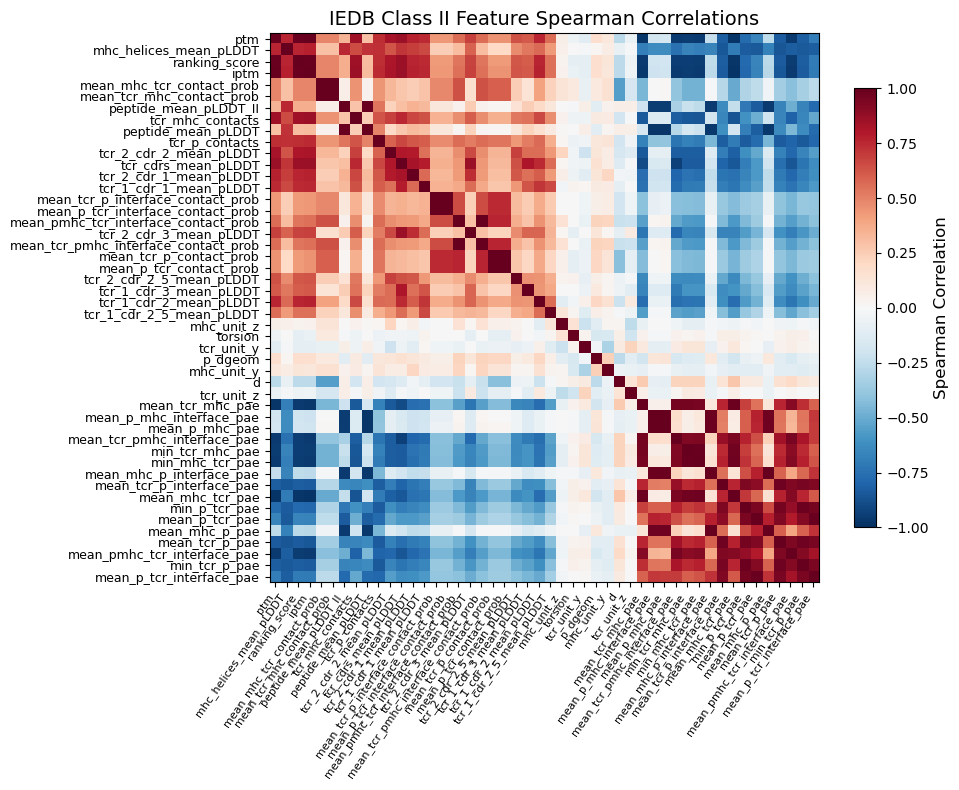

In [9]:
fn_II = (
    feat_df_II.sort(by="auc", descending=True).select("featname").to_series().to_list()
)


_ = plot_spearman_heatmap(
    iedb_II, fn_II, title="IEDB Class II Feature Spearman Correlations"
)